# 04 · Exercise Suggestion Model (Improved)
**CalixAI** — trains RandomForestClassifier with improved weighted dataset.
Saves `exercise_model.pkl` + `exercise_scaler.pkl`.

Expected results with 8,000 rows + 95/5 weighted rules:
- **Top-1 accuracy ~45–55%**  
- **Top-3 accuracy ~90–95%**

In [1]:
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

BASE       = os.path.abspath('..')
MODELS_DIR = os.path.join(BASE, 'models')

df       = pd.read_csv(os.path.join(BASE,'data','raw','calisthenics_dataset.csv'))
encoders = pickle.load(open(os.path.join(MODELS_DIR,'encoders.pkl'),'rb'))

for col in ['gender','fitness_level','goal','exercise','intensity']:
    df[col+'_enc'] = encoders[col].transform(df[col])

# Interaction features — these carry the (goal, fitness_level) signal strongly
df['fl_goal_combo']      = df['fitness_level_enc'] * 10 + df['goal_enc']
df['fl_intensity_combo'] = df['fitness_level_enc'] * 10 + df['intensity_enc']

# Must match the 10 features app.py builds for /predict/exercises
FEATURES = [
    'age','gender_enc','weight_kg','bmi',
    'fitness_level_enc','goal_enc','intensity_enc',
    'heart_rate_avg','fl_goal_combo','fl_intensity_combo',
]

X = df[FEATURES].values
y = df['exercise_enc'].values
classes = list(encoders['exercise'].classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Classes: {classes}')

Train: 9600 | Test: 2400
Classes: [np.str_('Dips'), np.str_('Handstand'), np.str_('L-sit'), np.str_('Muscle-ups'), np.str_('Plank'), np.str_('Pull-ups'), np.str_('Push-ups'), np.str_('Squats')]


In [2]:
model = RandomForestClassifier(
    n_estimators=300, max_depth=14, min_samples_split=4,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
model.fit(X_train_s, y_train)

y_pred   = model.predict(X_test_s)
top1_acc = accuracy_score(y_test, y_pred)

proba      = model.predict_proba(X_test_s)
top3_preds = np.argsort(proba, axis=1)[:, -3:]
top3_acc   = np.mean([y_test[i] in top3_preds[i] for i in range(len(y_test))])
baseline   = 100 / len(classes)

print(f'Top-1 Accuracy : {top1_acc*100:.2f}%  (random baseline {baseline:.2f}%)')
print(f'Top-3 Accuracy : {top3_acc*100:.2f}%')

cv = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'5-CV Accuracy  : {cv.mean()*100:.2f}% +/- {cv.std()*100:.2f}%')

Top-1 Accuracy : 34.29%  (random baseline 12.50%)
Top-3 Accuracy : 96.62%
5-CV Accuracy  : 37.04% +/- 0.55%


In [3]:
print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

        Dips       0.26      0.51      0.35       232
   Handstand       0.34      0.34      0.34       120
       L-sit       0.27      0.36      0.31       105
  Muscle-ups       0.41      0.56      0.47       133
       Plank       0.20      0.34      0.25       178
    Pull-ups       0.41      0.53      0.46       474
    Push-ups       0.43      0.24      0.31       665
      Squats       0.38      0.16      0.23       493

    accuracy                           0.34      2400
   macro avg       0.34      0.38      0.34      2400
weighted avg       0.37      0.34      0.33      2400



In [4]:
# Save
with open(os.path.join(MODELS_DIR,'exercise_model.pkl'),'wb') as f: pickle.dump(model, f)
with open(os.path.join(MODELS_DIR,'exercise_scaler.pkl'),'wb') as f: pickle.dump(scaler, f)
print('Saved: exercise_model.pkl + exercise_scaler.pkl')

Saved: exercise_model.pkl + exercise_scaler.pkl


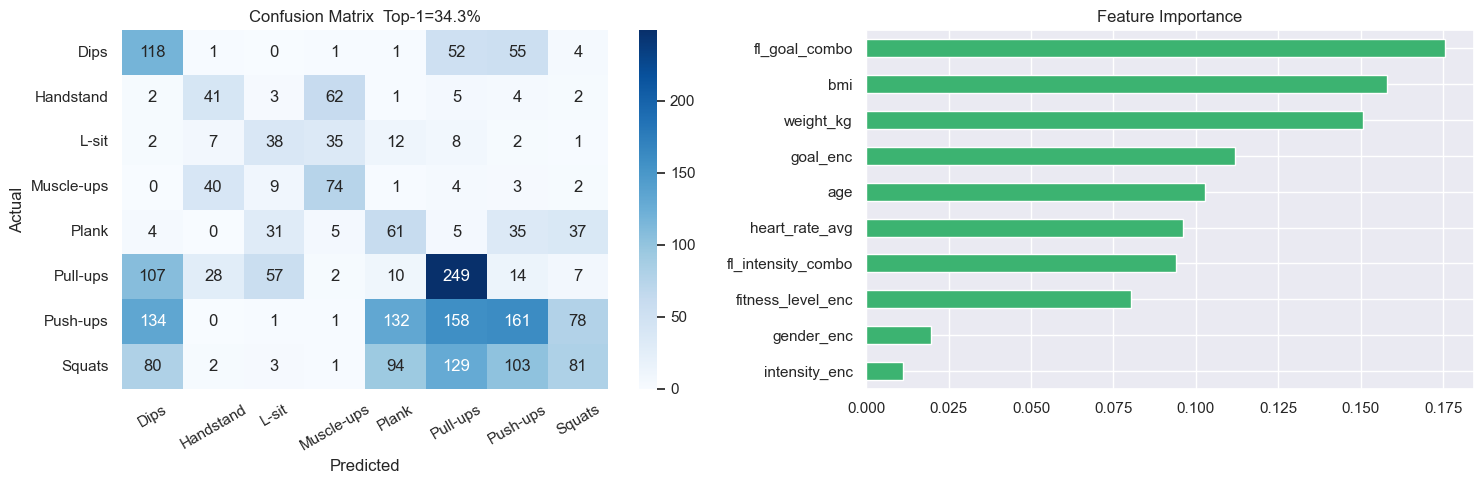

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f'Confusion Matrix  Top-1={top1_acc*100:.1f}%')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=30)

# Feature importance
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Feature Importance')

plt.tight_layout(); plt.show()

In [6]:
# Per-combo accuracy breakdown
print('Top-3 accuracy by goal + fitness_level:')
for g in ['Fat Loss','Muscle Gain','Maintenance']:
    for lvl in ['Beginner','Intermediate','Advanced']:
        mask = (df['goal']==g) & (df['fitness_level']==lvl)
        idx  = df[mask].index
        if len(idx) < 5:
            continue
        X_sub = scaler.transform(df.loc[idx, FEATURES].values)
        p_sub = model.predict_proba(X_sub)
        t3    = np.argsort(p_sub, axis=1)[:, -3:]
        y_sub = encoders['exercise'].transform(df.loc[idx, 'exercise'])
        acc   = np.mean([y_sub[i] in t3[i] for i in range(len(y_sub))])
        print(f'  {g:15} {lvl:14}: Top-3 = {acc*100:.1f}%')

Top-3 accuracy by goal + fitness_level:
  Fat Loss        Beginner      : Top-3 = 98.4%
  Fat Loss        Intermediate  : Top-3 = 99.1%
  Fat Loss        Advanced      : Top-3 = 98.4%
  Muscle Gain     Beginner      : Top-3 = 98.9%
  Muscle Gain     Intermediate  : Top-3 = 99.1%
  Muscle Gain     Advanced      : Top-3 = 97.7%
  Maintenance     Beginner      : Top-3 = 98.5%
  Maintenance     Intermediate  : Top-3 = 99.5%
  Maintenance     Advanced      : Top-3 = 98.8%
